# 15 · Respuesta multiescala a la frontera territorial — Bogotá 2023

**Objetivo EPJ Data Science.** Evaluar si la brecha mujer–hombre de accesibilidad estocástica cambia de forma gradual cuando la red pasa de una delimitación administrativa a ámbitos funcionales progresivamente más amplios.

## Protocolo prespecificado

- **Estimando:** brecha mujer–hombre de FPT y sus componentes residencial y de kernel, en cada alcance territorial.
- **Unidad analítica:** flujos OD ponderados entre UTAM; la incertidumbre se agrupa por hogar.
- **Alcances:** Bogotá D.C.; núcleo funcional que acumula al menos 50% y 80% del flujo bidireccional Bogotá–municipios externos; Bogotá–Región completa.
- **Selección territorial:** se ordenan municipios externos por flujo total con Bogotá usando la población completa, nunca por sexo ni por el resultado.
- **Targets:** se reconstruyen dentro de cada alcance con la misma regla core-50, soporte mínimo y ESS de Gates 6 y 12.
- **Inferencia:** 500 multiplicadores Poisson(1) compartidos por hogar y por todos los alcances.
- **Interpretación:** asociación descriptiva entre alcance funcional y desigualdad medida; no es un efecto causal de las fronteras.
- **Dependencias:** Gates 11, 12 y 13 aprobadas.


In [1]:
%pip -q install pandas pyarrow numpy scipy matplotlib seaborn geopandas networkx


In [2]:
from pathlib import Path
from datetime import datetime, timezone
import csv, json, os, re, shutil, unicodedata, zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("/content/colombia-stochastic-access")
RAW = ROOT / "data/raw/bogota_em2023"
INTERIM = ROOT / "data/interim/bogota_em2023_gate16"
OUT = ROOT / "outputs/bogota_em2023/gate16"
DRIVE_BASE = Path("/content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023")
for directory in (RAW, INTERIM, OUT):
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_URL = "https://observatorio.movilidadbogota.gov.co/sites/default/files/2025-09/05_Base%20datos%20procesada%20EODH.zip"
ZONING_URL = "https://observatorio.movilidadbogota.gov.co/sites/default/files/2025-09/03_Zonificacion%20EODH%20%281%29.zip"
PURPOSES = ("employment", "education", "health")
EFFECTS = ("female_minus_male_total", "residential_contribution", "kernel_contribution")
SEX_LEVELS = ("mujer", "hombre")
FLOW_THRESHOLDS = (0.50, 0.80)
TAU = 20.0
BOOTSTRAP_REPLICATES = 500
RANDOM_SEED = 202316
MIN_DESTINATION_SAMPLE = 5
MIN_DESTINATION_ESS = 3.0

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as exc:
    print(f"Entorno fuera de Colab o Drive no montado: {exc}")

G4 = Path(os.environ.get("GATE4_DIR_OVERRIDE", DRIVE_BASE / "results/gate4"))
G6 = Path(os.environ.get("GATE6_DIR_OVERRIDE", DRIVE_BASE / "results/gate6"))
G11 = Path(os.environ.get("GATE11_DIR_OVERRIDE", DRIVE_BASE / "results/gate11"))
G12 = Path(os.environ.get("GATE12_DIR_OVERRIDE", DRIVE_BASE / "results/gate12"))
G13 = Path(os.environ.get("GATE13_DIR_OVERRIDE", DRIVE_BASE / "results/gate13"))
paths = {
    "region_edges": G4 / "transition_edges_utam.parquet",
    "region_targets": G6 / "purpose_target_sets.csv",
    "region_point": G11 / "final_female_male_point_estimates.csv",
    "city_targets": G12 / "bogota_dc_internal_core50_targets.csv",
    "city_point": G12 / "bogota_dc_internal_female_male_point_estimates.csv",
    "gate11": G11 / "gate_11.json",
    "gate12": G12 / "gate_12.json",
    "gate13": G13 / "gate_13.json",
}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Faltan insumos validados: " + ", ".join(missing))

dependency_reports = {
    name: json.loads(paths[name].read_text(encoding="utf-8"))
    for name in ("gate11", "gate12", "gate13")
}
for number, name in ((11, "gate11"), (12, "gate12"), (13, "gate13")):
    if not dependency_reports[name].get("gate", {}).get(f"gate_{number}_passed", False):
        raise RuntimeError(f"Gate {number} no aprobada")

print("Alcances objetivo: Bogotá D.C. → funcional 50% → funcional 80% → región")
print("Réplicas pareadas:", BOOTSTRAP_REPLICATES)
print("Salida:", OUT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Alcances objetivo: Bogotá D.C. → funcional 50% → funcional 80% → región
Réplicas pareadas: 500
Salida: /content/colombia-stochastic-access/outputs/bogota_em2023/gate16


In [3]:
def valid_zip(path):
    path = Path(path)
    return path.exists() and path.stat().st_size > 0 and zipfile.is_zipfile(path)

def ensure_archive(runtime_name, drive_name, url, label):
    runtime = RAW / runtime_name
    cached = DRIVE_BASE / drive_name
    if valid_zip(runtime):
        return runtime, "runtime_cache"
    if valid_zip(cached):
        shutil.copy2(cached, runtime)
        return runtime, "google_drive_cache"
    from google.colab import files
    print(f"Descargue y seleccione el ZIP de {label}:\n{url}")
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Suba exactamente un ZIP")
    name, content = next(iter(uploaded.items()))
    temporary = runtime.with_suffix(".zip.upload")
    temporary.write_bytes(content)
    del content
    if not valid_zip(temporary):
        temporary.unlink(missing_ok=True)
        raise ValueError(f"{name} no es un ZIP válido")
    temporary.replace(runtime)
    DRIVE_BASE.mkdir(parents=True, exist_ok=True)
    shutil.copy2(runtime, cached)
    return runtime, "manual_upload"

def safe_extract_recursive(zip_path, destination):
    destination.mkdir(parents=True, exist_ok=True)
    queue = [(Path(zip_path), destination)]
    visited = set()
    while queue:
        current, target = queue.pop(0)
        signature = (str(current.resolve()), str(target.resolve()))
        if signature in visited:
            continue
        visited.add(signature)
        root = target.resolve()
        with zipfile.ZipFile(current) as zipped:
            for member in zipped.infolist():
                resolved = (target / member.filename).resolve()
                if root != resolved and root not in resolved.parents:
                    raise ValueError(f"Ruta insegura: {member.filename}")
            zipped.extractall(target)
        for nested in target.rglob("*.zip"):
            nested_target = nested.parent / nested.stem
            if (str(nested.resolve()), str(nested_target.resolve())) not in visited:
                queue.append((nested, nested_target))

survey_archive, survey_method = ensure_archive(
    "processed_edoh.zip", "processed_edoh.zip", SOURCE_URL, "microdatos"
)
zoning_archive, zoning_method = ensure_archive(
    "zoning_edoh.zip", "zoning_edoh.zip", ZONING_URL, "zonificación"
)
safe_extract_recursive(survey_archive, INTERIM / "processed_edoh")
safe_extract_recursive(zoning_archive, INTERIM / "zoning_edoh")
print("Microdatos:", survey_method, "| Zonificación:", zoning_method)


Microdatos: runtime_cache | Zonificación: runtime_cache


In [4]:
def normalize(value):
    value = unicodedata.normalize("NFKD", str(value))
    value = "".join(char for char in value if not unicodedata.combining(char))
    return re.sub(r"[^a-z0-9]+", "_", value.lower().strip()).strip("_")

def clean_key(series):
    cleaned = series.astype("string").str.strip().str.replace(r"\.0$", "", regex=True)
    return cleaned.mask(cleaned.map(normalize).isin(
        ["", "nan", "none", "na", "no_aplica", "sin_informacion"]
    ))

def canonical_utam(series):
    cleaned = clean_key(series)
    def one(value):
        if pd.isna(value):
            return pd.NA
        text = str(value).strip().upper().replace(" ", "")
        match = re.fullmatch(r"UPR0*(\d+)", text)
        if match:
            return f"UPR{int(match.group(1)):04d}"
        match = re.fullmatch(r"(?:UTAM)?0*(\d+)", text)
        return f"UTAM{int(match.group(1)):03d}" if match else text
    return cleaned.map(one).astype("string")

def parse_number(series):
    raw = series.astype("string").str.strip()
    if float(raw.str.contains(",", regex=False, na=False).mean()) > 0.05:
        raw = raw.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
    return pd.to_numeric(raw, errors="coerce")

def csv_format(path):
    for encoding in ("utf-8-sig", "latin-1"):
        try:
            with path.open("r", encoding=encoding, errors="strict") as handle:
                sample = handle.read(32768)
            return encoding, csv.Sniffer().sniff(sample, delimiters=",;\t|").delimiter
        except (UnicodeDecodeError, csv.Error):
            continue
    raise ValueError(f"Formato no detectado: {path}")

def find_module(token, excluded=()):
    candidates = [
        path for path in (INTERIM / "processed_edoh").rglob("*.csv")
        if token in normalize(path.stem)
        and not any(item in normalize(path.stem) for item in excluded)
    ]
    if not candidates:
        raise FileNotFoundError(token)
    return sorted(candidates, key=lambda path: (len(path.parts), len(path.name)))[0]

def read_selected(path, required):
    encoding, delimiter = csv_format(path)
    header = pd.read_csv(path, sep=delimiter, encoding=encoding, nrows=0)
    mapping = {normalize(column): column for column in header.columns}
    absent = sorted(set(required) - set(mapping))
    if absent:
        raise KeyError(f"Faltan columnas {absent}")
    frame = pd.read_csv(
        path, sep=delimiter, encoding=encoding,
        usecols=[mapping[column] for column in required],
        dtype="string", low_memory=False,
    )
    frame.columns = [normalize(column) for column in frame.columns]
    return frame

trips = read_selected(
    find_module("viaje", excluded=("etapa",)),
    ["key_hg", "utam_ori", "utam_des", "fexp_vj", "sexo", "motivo_viaje"],
)
persons = read_selected(
    find_module("persona"),
    ["key_hg", "cod_utam_hg", "fexp_per_5anos", "sexo"],
)
trips["household"] = clean_key(trips["key_hg"])
trips["utam_ori"] = canonical_utam(trips["utam_ori"])
trips["utam_des"] = canonical_utam(trips["utam_des"])
trips["weight"] = parse_number(trips["fexp_vj"])
trips["sex_group"] = trips["sexo"].map(normalize)
trips["purpose_normalized"] = trips["motivo_viaje"].map(normalize)
persons["household"] = clean_key(persons["key_hg"])
persons["residence_utam"] = canonical_utam(persons["cod_utam_hg"])
persons["weight"] = parse_number(persons["fexp_per_5anos"])
persons["sex_group"] = persons["sexo"].map(normalize)
trips = trips[
    trips[["household", "utam_ori", "utam_des"]].notna().all(axis=1)
    & trips["weight"].gt(0)
].reset_index(drop=True)
persons = persons[
    persons[["household", "residence_utam"]].notna().all(axis=1)
    & persons["weight"].gt(0)
].reset_index(drop=True)

PURPOSE_PATTERNS = {
    "employment": r"^a_trabajar$",
    "education": r"estudi|educa|coleg|univers|jardin|escuela",
    "health": r"salud|medic|hospital|clinic|consulta|terapia",
    "job_search": r"buscar_trabajo",
    "mobile_work": r"conduzco_vehiculo_como_forma_de_trabajo",
}
def classify_purpose(value):
    matches = [
        purpose for purpose, pattern in PURPOSE_PATTERNS.items()
        if re.search(pattern, value)
    ]
    return "ambiguous" if len(matches) > 1 else (matches[0] if matches else "other")
trips["purpose_group"] = trips["purpose_normalized"].map(classify_purpose)

spatial_paths = (
    list((INTERIM / "zoning_edoh").rglob("*.shp"))
    + list((INTERIM / "zoning_edoh").rglob("*.geojson"))
    + list((INTERIM / "zoning_edoh").rglob("*.gpkg"))
)
candidates = []
for path in spatial_paths:
    try:
        columns = {normalize(column): column for column in gpd.read_file(path, rows=5).columns}
        if "utam" in columns:
            candidates.append(path)
    except Exception:
        continue
if not candidates:
    raise FileNotFoundError("Capa UTAM")
utam_path = sorted(
    candidates, key=lambda path: ("utam2023" not in normalize(path.stem), len(path.parts))
)[0]
layer = gpd.read_file(utam_path)
column_map = {normalize(column): column for column in layer.columns}
municipality_key = (
    "munnombre" if "munnombre" in column_map
    else next(key for key in column_map if "mun" in key and "nombre" in key)
)
lookup = pd.DataFrame({
    "utam": canonical_utam(layer[column_map["utam"]]),
    "municipality": layer[column_map[municipality_key]].astype("string").str.strip(),
}).dropna().drop_duplicates("utam")
lookup["municipality_normalized"] = lookup["municipality"].map(normalize)
print("Viajes:", len(trips), "| Personas:", len(persons), "| Capa:", utam_path)


Viajes: 97796 | Personas: 64989 | Capa: /content/colombia-stochastic-access/data/interim/bogota_em2023_gate16/zoning_edoh/03_Zonificacion EODH/a. Shapefile UTAM/UTAM2023/UTAM2023.shp


In [5]:
edges = pd.read_parquet(paths["region_edges"])
edges["utam_ori"] = canonical_utam(edges["utam_ori"])
edges["utam_des"] = canonical_utam(edges["utam_des"])
region_nodes = sorted(set(edges["utam_ori"]) | set(edges["utam_des"]))
region_node_set = set(region_nodes)

node_municipality = lookup.set_index("utam")["municipality_normalized"].to_dict()
node_municipality_display = lookup.set_index("utam")["municipality"].to_dict()
mapping_coverage = float(pd.Series(region_nodes).map(node_municipality).notna().mean())
bogota_nodes = {
    node for node in region_nodes
    if "bogota" in str(node_municipality.get(node, ""))
}
if not bogota_nodes:
    raise RuntimeError("No se identificaron nodos de Bogotá")

region_trips = trips[
    trips["utam_ori"].isin(region_node_set)
    & trips["utam_des"].isin(region_node_set)
].copy()
region_persons = persons[persons["residence_utam"].isin(region_node_set)].copy()
region_trips["origin_municipality"] = region_trips["utam_ori"].map(node_municipality)
region_trips["destination_municipality"] = region_trips["utam_des"].map(node_municipality)
origin_bogota = region_trips["origin_municipality"].str.contains("bogota", na=False)
destination_bogota = region_trips["destination_municipality"].str.contains("bogota", na=False)
interface = region_trips[origin_bogota ^ destination_bogota].copy()
interface["external_municipality"] = np.where(
    origin_bogota[interface.index],
    interface["destination_municipality"],
    interface["origin_municipality"],
)
interface_rank = (
    interface.groupby("external_municipality", observed=True)["weight"]
    .sum().sort_values(ascending=False).rename("interface_weight").reset_index()
)
if interface_rank.empty:
    raise RuntimeError("No se observaron flujos Bogotá–municipios externos")
interface_rank["rank"] = np.arange(1, len(interface_rank) + 1)
interface_rank["interface_share"] = (
    interface_rank["interface_weight"] / interface_rank["interface_weight"].sum()
)
interface_rank["cumulative_interface_share"] = interface_rank["interface_share"].cumsum()

def municipalities_to_threshold(threshold):
    crossing = np.flatnonzero(
        interface_rank["cumulative_interface_share"].to_numpy(float) >= threshold
    )
    number = int(crossing[0] + 1) if len(crossing) else len(interface_rank)
    return list(interface_rank.head(number)["external_municipality"])

external_region_municipalities = sorted({
    node_municipality[node] for node in region_nodes
    if node not in bogota_nodes and node_municipality.get(node)
})
scope_municipalities = {
    "bogota_dc": [],
    "functional_50": municipalities_to_threshold(0.50),
    "functional_80": municipalities_to_threshold(0.80),
    "bogota_region": external_region_municipalities,
}
SCOPE_ORDER = ("bogota_dc", "functional_50", "functional_80", "bogota_region")
SCOPE_LABELS = {
    "bogota_dc": "Bogotá D.C.",
    "functional_50": "Functional 50%",
    "functional_80": "Functional 80%",
    "bogota_region": "Bogotá Region",
}

all_households = pd.Index(sorted(
    set(region_trips["household"].astype(str))
    | set(region_persons["household"].astype(str))
))
household_to_code = {household: index for index, household in enumerate(all_households)}
target_rows = []

def build_scope(scope_name, external_municipalities):
    allowed_municipalities = set(external_municipalities)
    # The full-region endpoint must preserve every validated Gate 4 node,
    # including nodes without a municipality label. Intermediate functional
    # scopes remain selected only from observed Bogotá–municipality flows.
    if scope_name == "bogota_region":
        candidate_nodes = set(region_node_set)
    else:
        candidate_nodes = {
            node for node in region_nodes
            if node in bogota_nodes
            or node_municipality.get(node) in allowed_municipalities
        }
    internal = region_trips[
        region_trips["utam_ori"].isin(candidate_nodes)
        & region_trips["utam_des"].isin(candidate_nodes)
    ].copy()
    graph = nx.DiGraph()
    grouped = internal.groupby(
        ["utam_ori", "utam_des"], observed=True
    )["weight"].sum()
    graph.add_weighted_edges_from(
        (origin, destination, float(weight))
        for (origin, destination), weight in grouped.items()
    )
    components = sorted(nx.strongly_connected_components(graph), key=len, reverse=True)
    if not components:
        raise RuntimeError(f"{scope_name}: red vacía")
    nodes = sorted(components[0])
    node_set = set(nodes)
    node_to_index = {node: index for index, node in enumerate(nodes)}
    internal_before = internal
    internal = internal[
        internal["utam_ori"].isin(node_set)
        & internal["utam_des"].isin(node_set)
    ].reset_index(drop=True)
    residents_before = region_persons[
        region_persons["residence_utam"].isin(candidate_nodes)
    ].copy()
    residents = residents_before[
        residents_before["residence_utam"].isin(node_set)
    ].reset_index(drop=True)
    n = len(nodes)
    origin = internal["utam_ori"].map(node_to_index).to_numpy(dtype=int)
    destination = internal["utam_des"].map(node_to_index).to_numpy(dtype=int)
    trip_weight = internal["weight"].to_numpy(dtype=float)
    W0 = np.zeros((n, n), dtype=float)
    np.add.at(W0, (origin, destination), trip_weight)
    row_sum = W0.sum(axis=1)
    if np.any(row_sum <= 0):
        raise RuntimeError(f"{scope_name}: filas sin salida")
    P0 = W0 / row_sum[:, None]

    purpose_trips = internal[internal["purpose_group"].isin(PURPOSES)].copy()
    purpose_trips["weight_sq"] = purpose_trips["weight"] ** 2
    support = purpose_trips.groupby(
        ["purpose_group", "utam_des"], observed=True
    ).agg(
        sampled_trips=("weight", "size"),
        weighted_trips=("weight", "sum"),
        sum_weight_sq=("weight_sq", "sum"),
    ).reset_index()
    support["effective_sample_size"] = (
        support["weighted_trips"] ** 2
        / support["sum_weight_sq"].replace(0, np.nan)
    )
    support["supported"] = (
        support["sampled_trips"].ge(MIN_DESTINATION_SAMPLE)
        & support["effective_sample_size"].ge(MIN_DESTINATION_ESS)
    )
    targets = {}
    for purpose in PURPOSES:
        ranked = support[
            support["purpose_group"].eq(purpose) & support["supported"]
        ].sort_values("weighted_trips", ascending=False).copy()
        if ranked.empty:
            raise RuntimeError(f"{scope_name}/{purpose}: sin destinos soportados")
        ranked["rank"] = np.arange(1, len(ranked) + 1)
        ranked["cumulative_supported_share"] = (
            ranked["weighted_trips"].cumsum() / ranked["weighted_trips"].sum()
        )
        crossing = np.flatnonzero(
            ranked["cumulative_supported_share"].to_numpy(float) >= 0.50
        )
        number = int(crossing[0] + 1) if len(crossing) else len(ranked)
        selected = ranked.head(number)
        targets[purpose] = np.array(
            sorted(node_to_index[node] for node in selected["utam_des"]), dtype=int
        )
        for row in selected.itertuples(index=False):
            target_rows.append({
                "scope": scope_name,
                "purpose_group": purpose,
                "target_definition": "core_50",
                "utam": row.utam_des,
                "rank": int(row.rank),
                "weighted_trips": float(row.weighted_trips),
                "effective_sample_size": float(row.effective_sample_size),
                "cumulative_supported_share": float(row.cumulative_supported_share),
            })

    selected_interface_weight = interface_rank.loc[
        interface_rank["external_municipality"].isin(allowed_municipalities),
        "interface_weight",
    ].sum()
    realized_share = float(
        selected_interface_weight / interface_rank["interface_weight"].sum()
    )
    return {
        "name": scope_name,
        "nodes": nodes,
        "node_set": node_set,
        "n": n,
        "P0": P0,
        "targets": targets,
        "trips": internal,
        "persons": residents,
        "origin": origin,
        "destination": destination,
        "trip_weight": trip_weight,
        "residence": residents["residence_utam"].map(node_to_index).to_numpy(dtype=int),
        "person_weight": residents["weight"].to_numpy(dtype=float),
        "trip_hh": internal["household"].astype(str).map(household_to_code).to_numpy(dtype=int),
        "person_hh": residents["household"].astype(str).map(household_to_code).to_numpy(dtype=int),
        "trip_masks": {
            level: internal["sex_group"].eq(level).fillna(False).to_numpy(dtype=bool)
            for level in SEX_LEVELS
        },
        "person_masks": {
            level: residents["sex_group"].eq(level).fillna(False).to_numpy(dtype=bool)
            for level in SEX_LEVELS
        },
        "candidate_nodes": len(candidate_nodes),
        "trip_weight_scc_coverage": float(
            internal["weight"].sum() / internal_before["weight"].sum()
        ),
        "person_weight_scc_coverage": float(
            residents["weight"].sum() / residents_before["weight"].sum()
        ),
        "interface_share": realized_share,
        "external_municipalities": tuple(external_municipalities),
    }

scopes = {
    scope_name: build_scope(scope_name, scope_municipalities[scope_name])
    for scope_name in SCOPE_ORDER
}
scope_definitions = pd.DataFrame([
    {
        "scope_order": order,
        "scope": scope_name,
        "scope_label": SCOPE_LABELS[scope_name],
        "interface_share": scopes[scope_name]["interface_share"],
        "external_municipality_count": len(scopes[scope_name]["external_municipalities"]),
        "external_municipalities": "; ".join(scopes[scope_name]["external_municipalities"]),
        "candidate_nodes": scopes[scope_name]["candidate_nodes"],
        "largest_scc_nodes": scopes[scope_name]["n"],
        "trip_rows": len(scopes[scope_name]["trips"]),
        "person_rows": len(scopes[scope_name]["persons"]),
        "trip_weight_scc_coverage": scopes[scope_name]["trip_weight_scc_coverage"],
        "person_weight_scc_coverage": scopes[scope_name]["person_weight_scc_coverage"],
    }
    for order, scope_name in enumerate(SCOPE_ORDER)
])
targets_table = pd.DataFrame(target_rows)
scope_definitions.to_csv(OUT / "boundary_scope_definitions.csv", index=False)
targets_table.to_csv(OUT / "boundary_scope_targets.csv", index=False)
interface_rank.to_csv(OUT / "boundary_interface_municipality_ranking.csv", index=False)
display(interface_rank)
display(scope_definitions)


,external_municipality,interface_weight,rank,interface_share,cumulative_interface_share
0,soacha,489564.6,1,0.564198,0.564198
1,mosquera,76885.7,2,0.088607,0.652805
2,chia,73890.1,3,0.085155,0.737959
3,funza,42627.5,4,0.049126,0.787085
4,cota,31834.8,5,0.036688,0.823773
5,madrid,29655.9,6,0.034177,0.85795
6,cajica,27387.7,7,0.031563,0.889513
7,zipaquira,18485.3,8,0.021303,0.910816
8,la_calera,12993.2,9,0.014974,0.92579
9,facatativa,11009.7,10,0.012688,0.938478


,scope_order,scope,scope_label,interface_share,external_municipality_count,external_municipalities,candidate_nodes,largest_scc_nodes,trip_rows,person_rows,trip_weight_scc_coverage,person_weight_scc_coverage
0,0,bogota_dc,Bogotá D.C.,0.000000,0,,114,114,76168,48373,1.0,1.0
1,1,functional_50,Functional 50%,0.564198,1,soacha,120,120,82066,52869,1.0,1.0
2,2,functional_80,Functional 80%,0.823773,5,soacha; mosquera; chia; funza; cota,125,125,86576,56089,1.0,1.0
3,3,bogota_region,Bogotá Region,1.000000,20,bojaca; cajica; chia; choachi; cota; el_rosal;...,141,141,97796,64373,1.0,1.0


In [6]:
def regularized_kernel(scope, level, global_multiplier=None):
    mask = scope["trip_masks"][level]
    selected = np.flatnonzero(mask)
    original = scope["trip_weight"][selected]
    multiplicity = (
        np.ones(len(selected))
        if global_multiplier is None
        else global_multiplier[scope["trip_hh"][selected]].astype(float)
    )
    weights = original * multiplicity
    squared = original ** 2 * multiplicity
    origins = scope["origin"][selected]
    destinations = scope["destination"][selected]
    positive = weights > 0
    W = np.zeros((scope["n"], scope["n"]), dtype=float)
    np.add.at(
        W,
        (origins[positive], destinations[positive]),
        weights[positive],
    )
    out = W.sum(axis=1)
    sum_sq = np.bincount(
        origins[positive], weights=squared[positive], minlength=scope["n"]
    )
    ess = np.divide(
        out ** 2, sum_sq, out=np.zeros(scope["n"]), where=sum_sq > 0
    )
    empirical = np.zeros_like(W)
    observed = out > 0
    empirical[observed] = W[observed] / out[observed, None]
    omega = ess / (ess + TAU)
    return omega[:, None] * empirical + (1.0 - omega[:, None]) * scope["P0"]

def residential_distribution(scope, level, global_multiplier=None):
    mask = scope["person_masks"][level]
    selected = np.flatnonzero(mask)
    multiplicity = (
        np.ones(len(selected))
        if global_multiplier is None
        else global_multiplier[scope["person_hh"][selected]].astype(float)
    )
    mu = np.bincount(
        scope["residence"][selected],
        weights=scope["person_weight"][selected] * multiplicity,
        minlength=scope["n"],
    ).astype(float)
    if not np.isfinite(mu).all() or mu.sum() <= 0:
        raise RuntimeError(f"{scope['name']}/{level}: distribución residencial vacía")
    return mu / mu.sum()

def first_passage(scope, P, targets):
    target_mask = np.zeros(scope["n"], dtype=bool)
    target_mask[targets] = True
    transient = np.flatnonzero(~target_mask)
    h = np.zeros(scope["n"])
    h[transient] = np.linalg.solve(
        np.eye(len(transient)) - P[np.ix_(transient, transient)],
        np.ones(len(transient)),
    )
    return h

def condition(mu, targets):
    result = mu.copy()
    result[targets] = 0.0
    if result.sum() <= 0:
        raise RuntimeError("Masa fuera del target vacía")
    return result / result.sum()

def gap_values(h_w, h_m, mu_w, mu_m, targets):
    mu_w = condition(mu_w, targets)
    mu_m = condition(mu_m, targets)
    mm = float(mu_m @ h_m)
    mw = float(mu_w @ h_m)
    wm = float(mu_m @ h_w)
    ww = float(mu_w @ h_w)
    residence = 0.5 * ((mw - mm) + (ww - wm))
    kernel = 0.5 * ((wm - mm) + (ww - mw))
    total = ww - mm
    return {
        "male_total_fpt": mm,
        "female_total_fpt": ww,
        "female_minus_male_total": total,
        "residential_contribution": residence,
        "kernel_contribution": kernel,
        "closure_error": total - residence - kernel,
    }

def evaluate_scope(scope, multiplier=None):
    kernels = {
        level: regularized_kernel(scope, level, multiplier)
        for level in SEX_LEVELS
    }
    mus = {
        level: residential_distribution(scope, level, multiplier)
        for level in SEX_LEVELS
    }
    result = {}
    for purpose in PURPOSES:
        targets = scope["targets"][purpose]
        result[purpose] = gap_values(
            first_passage(scope, kernels["mujer"], targets),
            first_passage(scope, kernels["hombre"], targets),
            mus["mujer"], mus["hombre"], targets,
        )
    return result

point_rows = []
for scope_name in SCOPE_ORDER:
    values = evaluate_scope(scopes[scope_name])
    for purpose in PURPOSES:
        point_rows.append({
            "scope": scope_name,
            "scope_order": SCOPE_ORDER.index(scope_name),
            "interface_share": scopes[scope_name]["interface_share"],
            "purpose_group": purpose,
            **values[purpose],
        })
scope_points = pd.DataFrame(point_rows)
scope_points.to_csv(OUT / "boundary_multiscale_point_estimates.csv", index=False)

validated_points = pd.concat([
    pd.read_csv(paths["city_point"]).assign(scope="bogota_dc"),
    pd.read_csv(paths["region_point"]).assign(scope="bogota_region"),
], ignore_index=True)
endpoint_points = scope_points[
    scope_points["scope"].isin(["bogota_dc", "bogota_region"])
]
point_check = endpoint_points.merge(
    validated_points, on=["scope", "purpose_group"], suffixes=("_new", "_validated")
)
point_replication_error = max(
    float(
        (
            point_check[f"{effect}_new"]
            - point_check[f"{effect}_validated"]
        ).abs().max()
    )
    for effect in EFFECTS
)

def target_sets_from_file(path):
    frame = pd.read_csv(path, dtype={"utam": "string"})
    frame["utam"] = canonical_utam(frame["utam"])
    if "target_definition" in frame.columns:
        frame = frame[frame["target_definition"].eq("core_50")]
    return {
        purpose: set(frame.loc[frame["purpose_group"].eq(purpose), "utam"])
        for purpose in PURPOSES
    }

validated_target_sets = {
    "bogota_dc": target_sets_from_file(paths["city_targets"]),
    "bogota_region": target_sets_from_file(paths["region_targets"]),
}
generated_target_sets = {
    scope_name: {
        purpose: set(
            targets_table.loc[
                targets_table["scope"].eq(scope_name)
                & targets_table["purpose_group"].eq(purpose),
                "utam",
            ]
        )
        for purpose in PURPOSES
    }
    for scope_name in ("bogota_dc", "bogota_region")
}
targets_reproduced = all(
    generated_target_sets[scope_name][purpose]
    == validated_target_sets[scope_name][purpose]
    for scope_name in ("bogota_dc", "bogota_region")
    for purpose in PURPOSES
)

region_reference_nodes = region_nodes
region_reference_index = {node: index for index, node in enumerate(region_reference_nodes)}
reference_P0 = np.zeros((len(region_reference_nodes), len(region_reference_nodes)))
for row in edges.itertuples(index=False):
    reference_P0[
        region_reference_index[row.utam_ori],
        region_reference_index[row.utam_des],
    ] = float(row.transition_probability)
full_scope = scopes["bogota_region"]
same_region_nodes = full_scope["nodes"] == region_reference_nodes
if same_region_nodes:
    region_kernel_replication_error = float(
        np.max(np.abs(full_scope["P0"] - reference_P0))
    )
else:
    region_kernel_replication_error = float("inf")

display(scope_points)
print("Error máximo de puntos extremos:", point_replication_error)
print("Error máximo del kernel regional:", region_kernel_replication_error)
print("Targets extremos reproducidos:", targets_reproduced)


,scope,scope_order,interface_share,purpose_group,male_total_fpt,female_total_fpt,female_minus_male_total,residential_contribution,kernel_contribution,closure_error
0,bogota_dc,0,0.000000,employment,3.615614,4.094660,0.479046,-0.010416,0.489462,0.0
1,bogota_dc,0,0.000000,education,3.788828,4.187444,0.398616,0.009867,0.388749,0.0
2,bogota_dc,0,0.000000,health,5.044780,5.285235,0.240455,-0.001060,0.241515,0.0
3,functional_50,1,0.564198,employment,3.732865,4.430724,0.697859,-0.013548,0.711407,0.0
4,functional_50,1,0.564198,education,3.896647,4.232031,0.335385,0.013941,0.321443,0.0
5,functional_50,1,0.564198,health,5.123878,5.609658,0.485780,-0.008467,0.494247,0.0
6,functional_80,2,0.823773,employment,3.801042,4.523370,0.722328,-0.016696,0.739024,0.0
7,functional_80,2,0.823773,education,4.040869,4.474955,0.434086,0.004943,0.429144,0.0
8,functional_80,2,0.823773,health,5.300858,5.735175,0.434317,-0.014227,0.448544,0.0
9,bogota_region,3,1.000000,employment,4.111272,5.110021,0.998749,-0.032536,1.031285,0.0


Error máximo de puntos extremos: 1.7763568394002505e-15
Error máximo del kernel regional: 1.6653345369377348e-15
Targets extremos reproducidos: True


In [7]:
rng = np.random.default_rng(RANDOM_SEED)
bootstrap_rows = []
contrast_rows = []
for replicate in range(1, BOOTSTRAP_REPLICATES + 1):
    multiplier = rng.poisson(1, len(all_households))
    result = {}
    for scope_name in SCOPE_ORDER:
        result[scope_name] = evaluate_scope(scopes[scope_name], multiplier)
        for purpose in PURPOSES:
            bootstrap_rows.append({
                "replicate": replicate,
                "scope": scope_name,
                "scope_order": SCOPE_ORDER.index(scope_name),
                "interface_share": scopes[scope_name]["interface_share"],
                "purpose_group": purpose,
                **result[scope_name][purpose],
            })
    for scope_name in SCOPE_ORDER[1:]:
        for purpose in PURPOSES:
            row = {
                "replicate": replicate,
                "scope": scope_name,
                "reference_scope": "bogota_dc",
                "interface_share": scopes[scope_name]["interface_share"],
                "purpose_group": purpose,
            }
            for effect in EFFECTS:
                row[f"scope_minus_city__{effect}"] = (
                    result[scope_name][purpose][effect]
                    - result["bogota_dc"][purpose][effect]
                )
            city_gap = result["bogota_dc"][purpose]["female_minus_male_total"]
            row["relative_amplification"] = (
                result[scope_name][purpose]["female_minus_male_total"] / city_gap - 1.0
                if abs(city_gap) > 1e-12 else np.nan
            )
            contrast_rows.append(row)
    if replicate % 50 == 0:
        print(f"Bootstrap multiescala {replicate}/{BOOTSTRAP_REPLICATES}")

scope_bootstrap = pd.DataFrame(bootstrap_rows)
scope_contrasts = pd.DataFrame(contrast_rows)
scope_bootstrap.to_parquet(
    OUT / "boundary_multiscale_household_bootstrap.parquet", index=False
)
scope_contrasts.to_parquet(
    OUT / "boundary_multiscale_contrasts_bootstrap.parquet", index=False
)

city_point = scope_points[
    scope_points["scope"].eq("bogota_dc")
].set_index("purpose_group")
contrast_point_rows = []
for scope_name in SCOPE_ORDER[1:]:
    current = scope_points[
        scope_points["scope"].eq(scope_name)
    ].set_index("purpose_group")
    for purpose in PURPOSES:
        row = {
            "scope": scope_name,
            "reference_scope": "bogota_dc",
            "interface_share": scopes[scope_name]["interface_share"],
            "purpose_group": purpose,
        }
        for effect in EFFECTS:
            row[f"scope_minus_city__{effect}"] = float(
                current.loc[purpose, effect] - city_point.loc[purpose, effect]
            )
        city_gap = float(city_point.loc[purpose, "female_minus_male_total"])
        row["relative_amplification"] = float(
            current.loc[purpose, "female_minus_male_total"] / city_gap - 1.0
        )
        contrast_point_rows.append(row)
contrast_points = pd.DataFrame(contrast_point_rows)
contrast_points.to_csv(
    OUT / "boundary_multiscale_contrast_points.csv", index=False
)
display(contrast_points)


Bootstrap multiescala 50/500
Bootstrap multiescala 100/500
Bootstrap multiescala 150/500
Bootstrap multiescala 200/500
Bootstrap multiescala 250/500
Bootstrap multiescala 300/500
Bootstrap multiescala 350/500
Bootstrap multiescala 400/500
Bootstrap multiescala 450/500
Bootstrap multiescala 500/500


,scope,reference_scope,interface_share,purpose_group,scope_minus_city__female_minus_male_total,scope_minus_city__residential_contribution,scope_minus_city__kernel_contribution,relative_amplification
0,functional_50,bogota_dc,0.564198,employment,0.218813,-0.003132,0.221945,0.456767
1,functional_50,bogota_dc,0.564198,education,-0.063231,0.004074,-0.067306,-0.158627
2,functional_50,bogota_dc,0.564198,health,0.245326,-0.007406,0.252732,1.020257
3,functional_80,bogota_dc,0.823773,employment,0.243282,-0.006280,0.249562,0.507846
4,functional_80,bogota_dc,0.823773,education,0.035471,-0.004924,0.040395,0.088984
5,functional_80,bogota_dc,0.823773,health,0.193862,-0.013166,0.207029,0.806233
6,bogota_region,bogota_dc,1.000000,employment,0.519702,-0.022121,0.541823,1.084869
7,bogota_region,bogota_dc,1.000000,education,0.428746,-0.022393,0.451139,1.075587
8,bogota_region,bogota_dc,1.000000,health,0.464911,-0.029684,0.494595,1.933466


In [8]:
def max_t_intervals(point_frame, bootstrap_frame, keys, effects):
    rows = []
    for effect in effects:
        point_series = point_frame.set_index(keys)[effect].sort_index()
        wide = bootstrap_frame.pivot(
            index="replicate", columns=keys, values=effect
        ).reindex(columns=point_series.index)
        standard_error = wide.std(axis=0).replace(0, np.nan)
        standardized = (
            wide.subtract(point_series, axis=1)
            .abs().divide(standard_error, axis=1)
        )
        critical = float(standardized.max(axis=1).quantile(0.95))
        for key in point_series.index:
            key_tuple = key if isinstance(key, tuple) else (key,)
            values = wide[key]
            estimate = float(point_series[key])
            sd = float(standard_error[key])
            row = dict(zip(keys, key_tuple))
            row.update({
                "effect": effect,
                "point_estimate": estimate,
                "bootstrap_mean": float(values.mean()),
                "bootstrap_sd": sd,
                "ci_lower": float(values.quantile(0.025)),
                "ci_upper": float(values.quantile(0.975)),
                "max_t_critical": critical,
                "simultaneous_ci_lower": estimate - critical * sd,
                "simultaneous_ci_upper": estimate + critical * sd,
            })
            rows.append(row)
    return pd.DataFrame(rows)

scope_intervals = max_t_intervals(
    scope_points,
    scope_bootstrap,
    ["scope", "purpose_group"],
    list(EFFECTS),
)
scope_intervals = scope_intervals.merge(
    scope_definitions[["scope", "scope_order", "scope_label", "interface_share"]],
    on="scope", how="left",
)
scope_intervals.to_csv(
    OUT / "boundary_multiscale_scope_intervals.csv", index=False
)

contrast_effects = [
    f"scope_minus_city__{effect}" for effect in EFFECTS
] + ["relative_amplification"]
contrast_intervals = max_t_intervals(
    contrast_points,
    scope_contrasts,
    ["scope", "purpose_group"],
    contrast_effects,
)
contrast_intervals = contrast_intervals.merge(
    scope_definitions[["scope", "scope_order", "scope_label", "interface_share"]],
    on="scope", how="left",
)
contrast_intervals.to_csv(
    OUT / "boundary_multiscale_contrast_intervals.csv", index=False
)

x_by_scope = {
    row.scope: float(row.interface_share)
    for row in scope_definitions.itertuples(index=False)
}
x = np.array([x_by_scope[scope_name] for scope_name in SCOPE_ORDER], dtype=float)

def slope(values):
    return float(np.polyfit(x, np.asarray(values, dtype=float), 1)[0])

slope_point_rows = []
slope_boot_rows = []
for purpose in PURPOSES:
    point_indexed = scope_points[
        scope_points["purpose_group"].eq(purpose)
    ].set_index("scope")
    for effect in EFFECTS:
        slope_point_rows.append({
            "purpose_group": purpose,
            "effect": effect,
            "point_slope": slope(
                point_indexed.loc[list(SCOPE_ORDER), effect]
            ),
            "point_monotone_nondecreasing": bool(
                np.all(np.diff(
                    point_indexed.loc[list(SCOPE_ORDER), effect].to_numpy(float)
                ) >= -1e-12)
            ),
        })
        for replicate in range(1, BOOTSTRAP_REPLICATES + 1):
            frame = scope_bootstrap[
                scope_bootstrap["replicate"].eq(replicate)
                & scope_bootstrap["purpose_group"].eq(purpose)
            ].set_index("scope")
            values = frame.loc[list(SCOPE_ORDER), effect].to_numpy(float)
            slope_boot_rows.append({
                "replicate": replicate,
                "purpose_group": purpose,
                "effect": effect,
                "slope": slope(values),
                "monotone_nondecreasing": bool(
                    np.all(np.diff(values) >= -1e-12)
                ),
            })

slope_points = pd.DataFrame(slope_point_rows)
slope_bootstrap = pd.DataFrame(slope_boot_rows)
slope_interval_rows = []
for effect in EFFECTS:
    wide = slope_bootstrap[
        slope_bootstrap["effect"].eq(effect)
    ].pivot(index="replicate", columns="purpose_group", values="slope").reindex(
        columns=PURPOSES
    )
    points = slope_points[
        slope_points["effect"].eq(effect)
    ].set_index("purpose_group")["point_slope"].reindex(PURPOSES)
    standard_error = wide.std(axis=0).replace(0, np.nan)
    critical = float(
        wide.subtract(points, axis=1).abs()
        .divide(standard_error, axis=1)
        .max(axis=1).quantile(0.95)
    )
    for purpose in PURPOSES:
        values = wide[purpose]
        estimate = float(points[purpose])
        sd = float(standard_error[purpose])
        monotone_probability = float(
            slope_bootstrap[
                slope_bootstrap["effect"].eq(effect)
                & slope_bootstrap["purpose_group"].eq(purpose)
            ]["monotone_nondecreasing"].mean()
        )
        slope_interval_rows.append({
            "purpose_group": purpose,
            "effect": effect,
            "point_slope": estimate,
            "bootstrap_mean": float(values.mean()),
            "bootstrap_sd": sd,
            "ci_lower": float(values.quantile(0.025)),
            "ci_upper": float(values.quantile(0.975)),
            "max_t_critical": critical,
            "simultaneous_ci_lower": estimate - critical * sd,
            "simultaneous_ci_upper": estimate + critical * sd,
            "point_monotone_nondecreasing": bool(
                slope_points[
                    slope_points["effect"].eq(effect)
                    & slope_points["purpose_group"].eq(purpose)
                ]["point_monotone_nondecreasing"].iloc[0]
            ),
            "bootstrap_monotone_probability": monotone_probability,
        })
slope_intervals = pd.DataFrame(slope_interval_rows)
slope_bootstrap.to_parquet(
    OUT / "boundary_multiscale_slope_bootstrap.parquet", index=False
)
slope_intervals.to_csv(
    OUT / "boundary_multiscale_slope_intervals.csv", index=False
)
display(slope_intervals)


,purpose_group,effect,point_slope,bootstrap_mean,bootstrap_sd,ci_lower,ci_upper,max_t_critical,simultaneous_ci_lower,simultaneous_ci_upper,point_monotone_nondecreasing,bootstrap_monotone_probability
0,employment,female_minus_male_total,0.450605,0.484011,0.118620,0.277628,0.725419,2.445623,0.160505,0.740704,True,0.756
1,education,female_minus_male_total,0.320145,0.350392,0.121138,0.142146,0.598754,2.445623,0.023886,0.616404,False,0.110
2,health,female_minus_male_total,0.390816,0.422461,0.138511,0.164003,0.725282,2.445623,0.052071,0.729562,False,0.212
3,employment,residential_contribution,-0.017917,-0.017433,0.017739,-0.051416,0.016763,2.284159,-0.058437,0.022603,False,0.020
4,education,residential_contribution,-0.017984,-0.017989,0.017104,-0.052829,0.013333,2.284159,-0.057052,0.021083,False,0.008
5,health,residential_contribution,-0.025740,-0.024412,0.020721,-0.065525,0.016586,2.284159,-0.073070,0.021590,False,0.006
6,employment,kernel_contribution,0.468521,0.501444,0.116363,0.304709,0.737450,2.522516,0.174993,0.762049,True,0.790
7,education,kernel_contribution,0.338129,0.368381,0.120234,0.162767,0.629185,2.522516,0.034838,0.641421,False,0.096
8,health,kernel_contribution,0.416557,0.446873,0.134263,0.203990,0.754247,2.522516,0.077876,0.755237,False,0.234


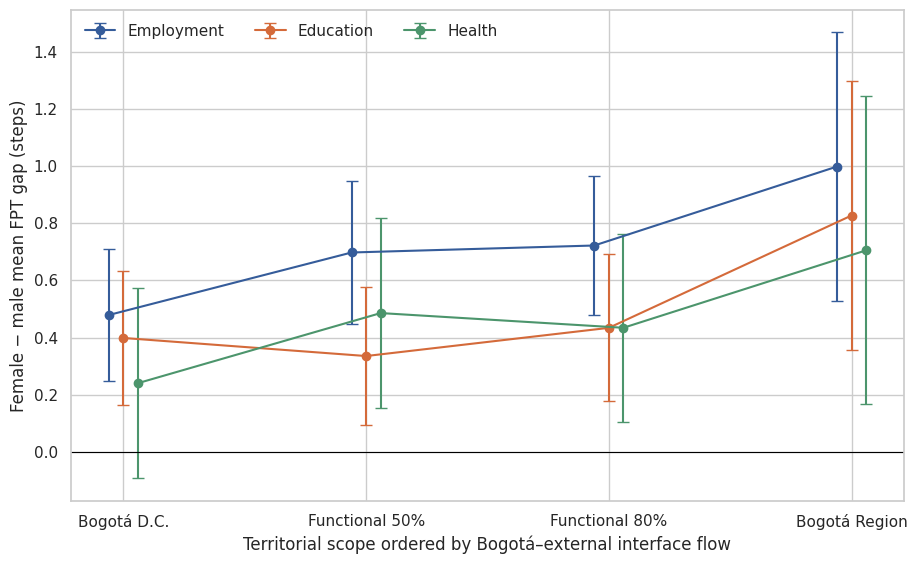

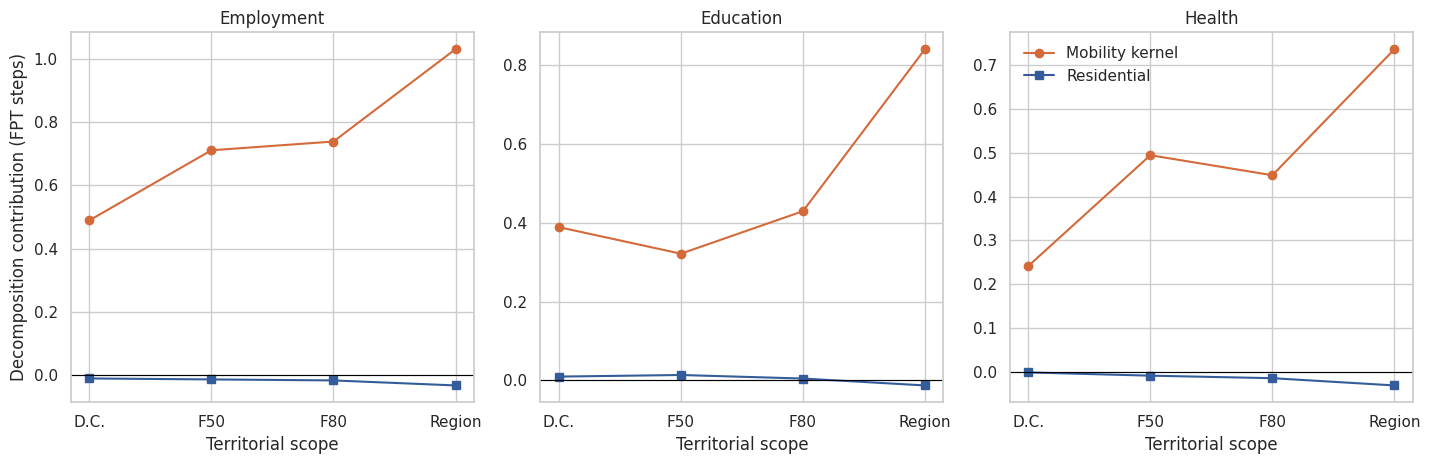

In [9]:
sns.set_theme(style="whitegrid", context="notebook")
purpose_labels = {
    "employment": "Employment",
    "education": "Education",
    "health": "Health",
}
scope_labels = [
    SCOPE_LABELS[scope_name] for scope_name in SCOPE_ORDER
]

total_plot = scope_intervals[
    scope_intervals["effect"].eq("female_minus_male_total")
].copy()
fig, axis = plt.subplots(figsize=(9.4, 5.8))
colors = {
    "employment": "#355C9A",
    "education": "#D46A3A",
    "health": "#4C956C",
}
for offset, purpose in zip((-0.06, 0.0, 0.06), PURPOSES):
    frame = (
        total_plot[total_plot["purpose_group"].eq(purpose)]
        .set_index("scope").loc[list(SCOPE_ORDER)]
    )
    xp = np.arange(len(SCOPE_ORDER)) + offset
    y = frame["point_estimate"].to_numpy(float)
    axis.errorbar(
        xp, y,
        yerr=[
            y - frame["simultaneous_ci_lower"].to_numpy(float),
            frame["simultaneous_ci_upper"].to_numpy(float) - y,
        ],
        marker="o", capsize=4, linewidth=1.5,
        color=colors[purpose], label=purpose_labels[purpose],
    )
axis.axhline(0, color="black", linewidth=0.8)
axis.set_xticks(np.arange(len(SCOPE_ORDER)))
axis.set_xticklabels(scope_labels)
axis.set(
    xlabel="Territorial scope ordered by Bogotá–external interface flow",
    ylabel="Female − male mean FPT gap (steps)",
)
axis.legend(frameon=False, ncol=3, loc="upper left")
fig.tight_layout()
fig.savefig(
    OUT / "figure_boundary_response_total_gap.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8), sharey=False)
for axis, purpose in zip(axes, PURPOSES):
    point = scope_points[
        scope_points["purpose_group"].eq(purpose)
    ].set_index("scope").loc[list(SCOPE_ORDER)]
    axis.plot(
        np.arange(len(SCOPE_ORDER)),
        point["kernel_contribution"],
        marker="o", color="#D46A3A", label="Mobility kernel",
    )
    axis.plot(
        np.arange(len(SCOPE_ORDER)),
        point["residential_contribution"],
        marker="s", color="#355C9A", label="Residential",
    )
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_xticks(np.arange(len(SCOPE_ORDER)))
    axis.set_xticklabels(["D.C.", "F50", "F80", "Region"])
    axis.set_title(purpose_labels[purpose])
    axis.set_xlabel("Territorial scope")
axes[0].set_ylabel("Decomposition contribution (FPT steps)")
axes[-1].legend(frameon=False)
fig.tight_layout()
fig.savefig(
    OUT / "figure_boundary_response_decomposition.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


In [10]:
thresholds = {
    "maximum_point_replication_error": 1e-8,
    "maximum_region_kernel_replication_error": 1e-10,
    "maximum_closure_error": 1e-10,
    "minimum_mapping_coverage": 0.99,
}
node_sets = [scopes[scope_name]["node_set"] for scope_name in SCOPE_ORDER]
checks = {
    "gate11_dependency_valid": bool(
        dependency_reports["gate11"]["gate"]["gate_11_passed"]
    ),
    "gate12_dependency_valid": bool(
        dependency_reports["gate12"]["gate"]["gate_12_passed"]
    ),
    "gate13_dependency_valid": bool(
        dependency_reports["gate13"]["gate"]["gate_13_passed"]
    ),
    "regional_node_municipality_mapping_valid": bool(
        mapping_coverage >= thresholds["minimum_mapping_coverage"]
    ),
    "four_scope_definitions_present": bool(
        list(scopes) == list(SCOPE_ORDER)
    ),
    "scope_node_sets_unique": bool(
        len({frozenset(node_set) for node_set in node_sets}) == len(SCOPE_ORDER)
    ),
    "scope_node_sets_nested": bool(
        all(node_sets[index] <= node_sets[index + 1]
            for index in range(len(node_sets) - 1))
    ),
    "interface_shares_strictly_increasing": bool(
        np.all(np.diff([
            scopes[scope_name]["interface_share"]
            for scope_name in SCOPE_ORDER
        ]) > 0)
    ),
    "all_scopes_row_stochastic": bool(
        all(np.allclose(scope["P0"].sum(axis=1), 1.0, atol=1e-10)
            for scope in scopes.values())
    ),
    "all_targets_nonempty": bool(
        all(len(scope["targets"][purpose]) > 0
            for scope in scopes.values() for purpose in PURPOSES)
    ),
    "endpoint_targets_reproduced": bool(targets_reproduced),
    "endpoint_points_reproduced": bool(
        point_replication_error <= thresholds["maximum_point_replication_error"]
    ),
    "regional_kernel_reproduced": bool(
        region_kernel_replication_error
        <= thresholds["maximum_region_kernel_replication_error"]
    ),
    "paired_bootstrap_500_complete": bool(
        scope_bootstrap["replicate"].nunique() == BOOTSTRAP_REPLICATES
        and len(scope_bootstrap)
        == BOOTSTRAP_REPLICATES * len(SCOPE_ORDER) * len(PURPOSES)
    ),
    "all_outputs_finite": bool(
        np.isfinite(
            scope_bootstrap.select_dtypes(include="number").to_numpy()
        ).all()
        and np.isfinite(
            scope_intervals.select_dtypes(include="number").to_numpy()
        ).all()
        and np.isfinite(
            contrast_intervals.select_dtypes(include="number").to_numpy()
        ).all()
        and np.isfinite(
            slope_intervals.select_dtypes(include="number").to_numpy()
        ).all()
    ),
    "decomposition_identity_valid": bool(
        scope_points["closure_error"].abs().max()
        <= thresholds["maximum_closure_error"]
    ),
    "slope_bootstrap_complete": bool(
        slope_bootstrap["replicate"].nunique() == BOOTSTRAP_REPLICATES
        and len(slope_bootstrap)
        == BOOTSTRAP_REPLICATES * len(PURPOSES) * len(EFFECTS)
    ),
}
checks["gate_16_passed"] = bool(all(checks.values()))

report = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "research_question": (
        "How does the female-minus-male stochastic-accessibility gap change "
        "as the mobility network expands from Bogotá D.C. to its functional region?"
    ),
    "estimand": (
        "scope-specific female-minus-male FPT gap, its symmetric residential/kernel "
        "decomposition, and the slope over realized Bogotá–external interface coverage"
    ),
    "scope_selection": (
        "external municipalities ranked by bidirectional survey-weighted flow with "
        "Bogotá using the full population; thresholds fixed at 50% and 80%"
    ),
    "bootstrap": {
        "method": "shared Poisson(1) household-cluster multipliers across all scopes",
        "replicates": BOOTSTRAP_REPLICATES,
        "seed": RANDOM_SEED,
    },
    "interpretation_boundary": (
        "descriptive/inferential sensitivity to territorial scope; neither the slope "
        "nor scope contrasts identify causal effects of municipal boundaries"
    ),
    "scope_definitions": json.loads(
        scope_definitions.to_json(orient="records")
    ),
    "point_estimates": json.loads(
        scope_points.to_json(orient="records")
    ),
    "contrast_intervals": json.loads(
        contrast_intervals.to_json(orient="records")
    ),
    "slope_intervals": json.loads(
        slope_intervals.to_json(orient="records")
    ),
    "thresholds": thresholds,
    "gate": checks,
}
(OUT / "gate_16.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2, allow_nan=False),
    encoding="utf-8",
)
pd.Series(checks, name="result").to_csv(
    OUT / "gate_16_checks.csv"
)
display(pd.Series(checks, name="result"))

persistent = DRIVE_BASE / "results/gate16"
persistent.mkdir(parents=True, exist_ok=True)
for artifact in OUT.iterdir():
    if artifact.is_file():
        shutil.copy2(artifact, persistent / artifact.name)

print("Compuerta 16:", "APROBADA" if checks["gate_16_passed"] else "NO APROBADA")
print("Copia persistente:", persistent)


,result
gate11_dependency_valid,True
gate12_dependency_valid,True
gate13_dependency_valid,True
regional_node_municipality_mapping_valid,True
four_scope_definitions_present,True
scope_node_sets_unique,True
scope_node_sets_nested,True
interface_shares_strictly_increasing,True
all_scopes_row_stochastic,True
all_targets_nonempty,True


Compuerta 16: APROBADA
Copia persistente: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate16


## Regla de interpretación científica

La compuerta valida el cálculo y la reproducibilidad, **no obliga a que la pendiente sea positiva**.

- Evidencia fuerte de amplificación multiescala: pendientes del gap total positivas con intervalos simultáneos por encima de cero y contrastes funcionales coherentes.
- Evidencia mixta: algunos propósitos aumentan y otros no, o la relación no es monótona.
- Ausencia de gradiente: el contraste D.C.–Región puede mantenerse como sensibilidad binaria, pero no debe describirse como una ley multiescala.
- En todos los casos, las conclusiones son descriptivas y no causales.
